In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
120 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 120 not upgraded.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [4]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng', 'korean-english-park.train.tar.gz', 'korean-english-news-v1']


In [5]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [6]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [7]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


In [8]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [9]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [10]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [11]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [12]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [13]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

In [14]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

In [15]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [16]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [18]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [20]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [21]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [23]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [24]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [25]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [26]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [27]:
 %%time

 EPOCHS = 10

 for epoch in range(EPOCHS):
     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:39<00:00,  9.46it/s, loss=1.88]


Epoch 1/10, Train Loss: 3.0971


Epoch 2: 100%|██████████| 375/375 [00:38<00:00,  9.68it/s, loss=1.28]


Epoch 2/10, Train Loss: 1.5474


Epoch 3: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.867]


...

Epoch 8/10, Train Loss: 0.2199


Epoch 9: 100%|██████████| 375/375 [00:38<00:00,  9.62it/s, loss=0.264]


Epoch 9/10, Train Loss: 0.2099


Epoch 10: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.258] 

Epoch 10/10, Train Loss: 0.2044
CPU times: user 6min 29s, sys: 5.25 s, total: 6min 34s
Wall time: 6min 30s


In [28]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [29]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:38<00:00,  9.63it/s, loss=0.196]


Epoch 1/20, Train Loss: 0.2004, Validation Loss: 1.7514


Epoch 2: 100%|██████████| 375/375 [00:38<00:00,  9.62it/s, loss=0.187] 


Epoch 2/20, Train Loss: 0.2002, Validation Loss: 1.7830


Epoch 3: 100%|██████████| 375/375 [00:39<00:00,  9.59it/s, loss=0.351]


...

Epoch 18/20, Train Loss: 0.1755, Validation Loss: 1.9765


Epoch 19: 100%|██████████| 375/375 [00:38<00:00,  9.64it/s, loss=0.205] 


Epoch 19/20, Train Loss: 0.1744, Validation Loss: 1.9900


Epoch 20: 100%|██████████| 375/375 [00:39<00:00,  9.58it/s, loss=0.217] 


Epoch 20/20, Train Loss: 0.1712, Validation Loss: 1.9652
CPU times: user 14min 9s, sys: 10.2 s, total: 14min 20s
Wall time: 14min 12s


In [30]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [31]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [32]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'hombre', 'agarr', 'leche', '.', '']


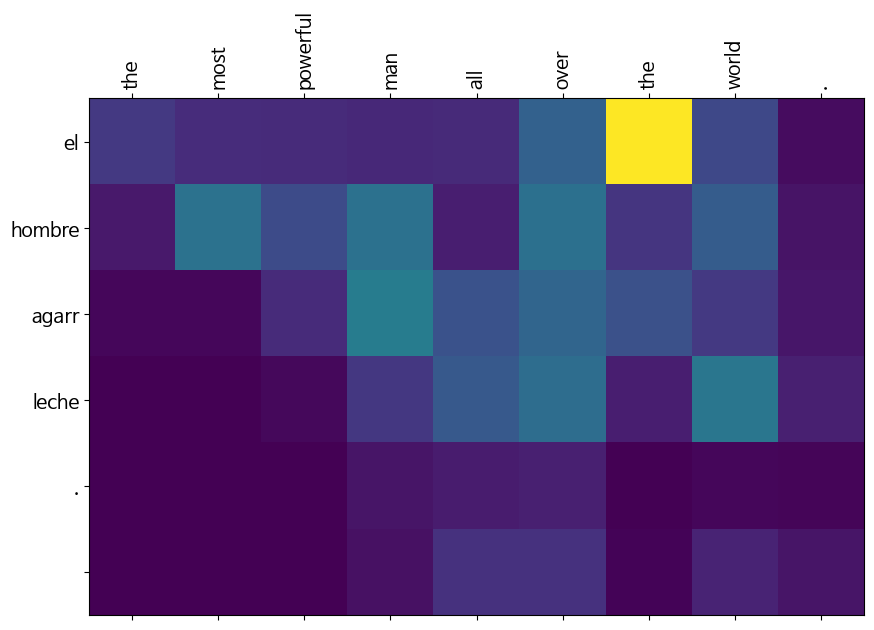

In [33]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'te', '?', '']


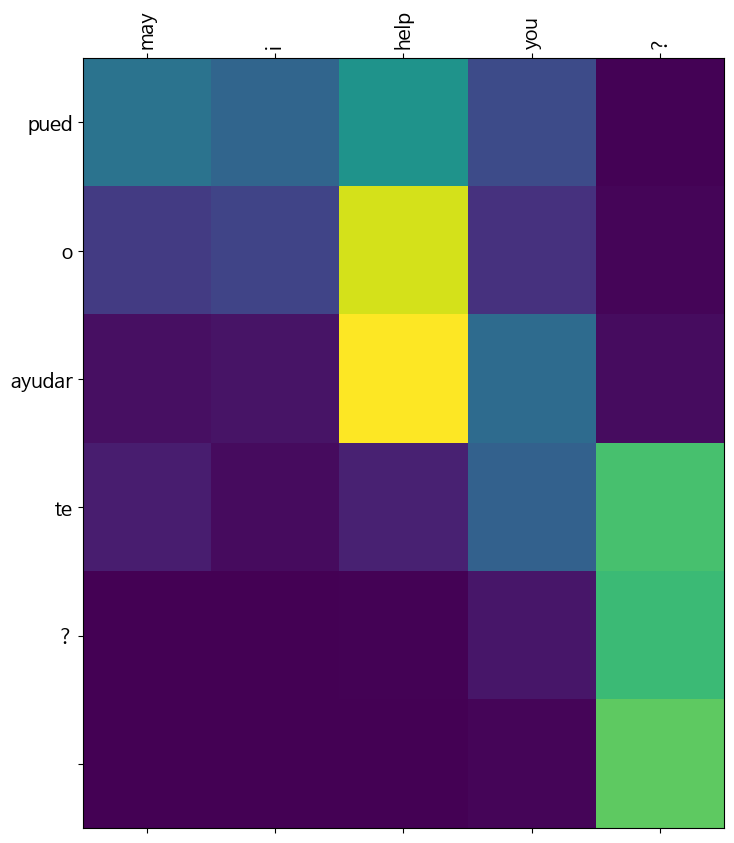

In [34]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['me', 'dan', 'un', 'poco', 'c', 'af', '?', '']


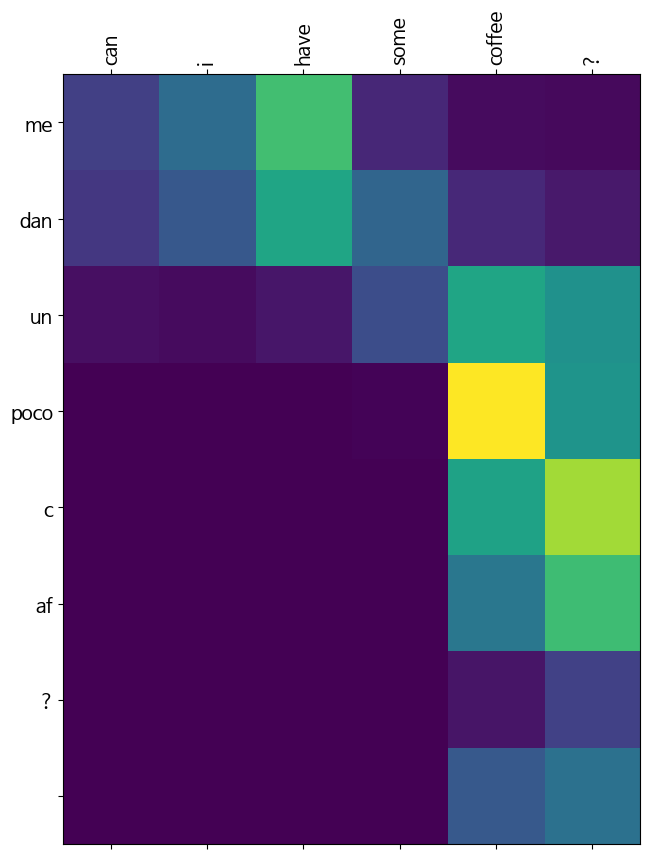

In [35]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

In [36]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


## step1. 데이터다운로드

In [37]:
import os
import urllib.request
import tarfile

# 1. 경로 설정
dataset_dir = "work/s2s_translation/datasets"
os.makedirs(dataset_dir, exist_ok=True)

# 2. 이미지(image_20d3db.png)의 경로를 반영한 URL 설정
file_name = "korean-english-park.train.tar.gz"
tar_path = os.path.join(dataset_dir, file_name)

# 깃허브 구조에 맞춘 정확한 Raw 파일 주소입니다.
url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 3. 데이터 다운로드 실행
if not os.path.exists(tar_path):
    print(f"{file_name} 다운로드 중...")
    # 브라우저인 것처럼 헤더를 추가하여 404/403 에러를 방지합니다.
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)
    
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")
else:
    print(f"파일이 이미 존재합니다: {tar_path}")

# 4. 압축 해제
data_folder = os.path.join(dataset_dir, "korean-english-news-v1")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    os.makedirs(data_folder, exist_ok=True)
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall(path=data_folder)
    print("압축 해제 완료!")

# 5. 결과 확인
print("생성된 파일 목록:", os.listdir(data_folder))

파일이 이미 존재합니다: work/s2s_translation/datasets/korean-english-park.train.tar.gz
생성된 파일 목록: ['korean-english-park.train.ko', 'korean-english-park.train.en']


In [38]:
# 1. KoNLPy 파이썬 라이브러리 설치
!pip install konlpy

# 2. Mecab 시스템 라이브러리 설치 (리눅스/Colab 환경 기준)
# 만약 윈도우(Windows) 환경이라면 이 부분은 동작하지 않으며 별도 설치가 필요합니다.
# 구글 코랩(Colab)이나 우분투(Ubuntu) 환경이라면 아래 명령어로 Mecab이 설치됩니다.
!sudo apt-get install -y curl git
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (8.5.0-2ubuntu10.7).
git is already the newest version (1:2.43.0-1ubuntu7.3).
0 upgraded, 0 newly installed, 0 to remove and 120 not upgraded.
mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [39]:
# 1. mecab-python3 라이브러리 설치 (파이썬 바인딩)
!pip install mecab-python3

# 2. MeCab 시스템 라이브러리 및 사전 설치 (약 1~2분 소요)
# Konlpy 공식 설치 스크립트를 사용하여 설치합니다.
!sudo apt-get update
!sudo apt-get install -y curl git
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease 
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Fetched 378 kB in 2s (211 kB/s)  
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (8.5.0-2ubuntu10.7).
git is already the newest version (1:2.43.0-1ubuntu7.3).
0 upgraded, 0 newly installed, 0 to remove and 120 not upgraded.
mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


In [40]:
import os
import re
from konlpy.tag import Mecab

# 1. 데이터 경로 설정 (이전 단계에서 압축을 푼 경로)
dataset_dir = "work/s2s_translation/datasets/korean-english-news-v1"
kor_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
eng_path = os.path.join(dataset_dir, "korean-english-park.train.en")

# 2. 데이터 불러오기
with open(kor_path, "r", encoding='utf-8') as f:
    kor_raw = f.read().splitlines()

with open(eng_path, "r", encoding='utf-8') as f:
    eng_raw = f.read().splitlines()

print(f"전체 데이터 개수: 한국어 {len(kor_raw)}개, 영어 {len(eng_raw)}개")

# 3. 중복 제거 (set 활용)
# zip으로 묶어 쌍을 유지한 채 중복 제거 후 다시 리스트로 변환
cleaned_corpus = list(set(zip(kor_raw, eng_raw)))
print(f"중복 제거 후 데이터 개수: {len(cleaned_corpus)}개")

# 4. 전처리 함수 재정의 (한글 포함)
def preprocess_sentence(sentence, s_token=False, e_token=False):
    sentence = sentence.lower().strip()

    # 문장 부호 양옆에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 여러 개의 공백을 하나의 공백으로 변환
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글(ㄱ-ㅎ, 가-힣), 영문(a-z, A-Z), 문장부호(?.!,)를 제외하고 모두 공백으로 변환
    sentence = re.sub(r"[^ㄱ-ㅎ가-힣a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()

    if s_token:
        sentence = '<start> ' + sentence

    if e_token:
        sentence += ' <end>'
    
    return sentence

# 5. 토큰화 및 길이 필터링 (Mecab, split 사용)
mecab = Mecab()
kor_corpus = []
eng_corpus = []

for kor, eng in cleaned_corpus:
    # 전처리 실행
    pre_kor = preprocess_sentence(kor)
    pre_eng = preprocess_sentence(eng, s_token=True, e_token=True)
    
    # 토큰화
    # 한국어: Mecab 형태소 분석
    kor_token = mecab.morphs(pre_kor)
    # 영어: 공백 기준 분리 (split)
    eng_token = pre_eng.split()
    
    # 길이 조건 (토큰 길이 40 이하)
    if len(kor_token) <= 40 and len(eng_token) <= 40:
        kor_corpus.append(kor_token)
        eng_corpus.append(eng_token)

print(f"최종 정제된 데이터 개수 (길이 40 이하): 한국어 {len(kor_corpus)}개, 영어 {len(eng_corpus)}개")
print("\n[샘플 출력]")
print("한국어:", kor_corpus[0])
print("영어:", eng_corpus[0])

전체 데이터 개수: 한국어 94123개, 영어 94123개
중복 제거 후 데이터 개수: 78968개
최종 정제된 데이터 개수 (길이 40 이하): 한국어 62733개, 영어 62733개

[샘플 출력]
한국어: ['러시아', '의', '인테르', '팍스', '통신', '은', '월요일', '에', '북한', '이', '주', '원자로', '를', '폐쇄', '할', '최종', '시한', '을', '결정', '했', '다고', '보도', '했', '다', '.', 'modalities', '양식']
영어: ['<start>', 'russia', 's', 'interfax', 'news', 'agency', 'reported', 'on', 'monday', 'that', 'the', 'north', 'had', 'set', 'a', 'deadline', 'by', 'which', 'to', 'shut', 'the', 'main', 'nuclear', 'reactor', '.', '<end>']


## step3. 데이터토큰화

In [41]:
!pip install tensorflow

In [42]:
import tensorflow as tf
import numpy as np

def tokenize(corpus):
    # 1. 토크나이저 객체 생성
    # num_words: 단어 빈도수가 높은 순으로 15,000개만 사용 (최소 10,000 이상 조건 충족)
    # filters='': 이미 전처리를 했으므로 토크나이저가 특수문자를 걸러내지 않도록 설정
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=15000, 
        filters=''
    )
    
    # 2. 단어장(Vocabulary) 생성
    tokenizer.fit_on_texts(corpus)

    # 3. 텍스트를 정수 시퀀스로 변환
    tensor = tokenizer.texts_to_sequences(corpus)

    # 4. 시퀀스 길이 맞추기 (Padding)
    # 문장 뒤쪽(post)에 0을 채워 길이를 맞춤
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, tokenizer

# 토큰화 수행
enc_tensor, enc_tokenizer = tokenize(kor_corpus)
dec_tensor, dec_tokenizer = tokenize(eng_corpus)

print("데이터 토큰화 완료!")
print(f"한국어 Tensor 크기: {enc_tensor.shape}")
print(f"영어 Tensor 크기: {dec_tensor.shape}")

# 단어 사전 크기 확인 (+1은 패딩 토큰 0을 고려한 것)
print(f"한국어 단어 사전 크기: {min(enc_tokenizer.num_words, len(enc_tokenizer.word_index) + 1)}")
print(f"영어 단어 사전 크기: {min(dec_tokenizer.num_words, len(dec_tokenizer.word_index) + 1)}")

# 주의: 지침에 따라 훈련 데이터와 검증 데이터를 따로 나누지 않습니다.

I0000 00:00:1773057123.737662    7507 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773057125.912982    7507 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


데이터 토큰화 완료!
한국어 Tensor 크기: (62733, 40)
영어 Tensor 크기: (62733, 40)
한국어 단어 사전 크기: 15000
영어 단어 사전 크기: 15000


## step4. 모델설계

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# GPU 사용 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 장치: {device}")

# 1. 인코더 (Encoder) 설계
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src shape: [src_len, batch_size]
        embedded = self.dropout(self.embedding(src))
        
        # outputs shape: [src_len, batch_size, hid_dim]
        # hidden shape: [1, batch_size, hid_dim]
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

# 2. 어텐션 (Attention) 설계 - Bahdanau Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim)      # 디코더의 이전 hidden state용
        self.U = nn.Linear(hid_dim, hid_dim)      # 인코더의 모든 output용
        self.v = nn.Linear(hid_dim, 1, bias=False) # 최종 스코어 계산용

    def forward(self, hidden, encoder_outputs):
        # hidden shape: [1, batch_size, hid_dim] -> [batch_size, hid_dim]
        # encoder_outputs shape: [src_len, batch_size, hid_dim] -> [batch_size, src_len, hid_dim]
        hidden = hidden.permute(1, 0, 2)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # attention score 계산
        score = torch.tanh(self.W(hidden) + self.U(encoder_outputs))
        attention_weights = F.softmax(self.v(score), dim=1)
        
        return attention_weights # shape: [batch_size, src_len, 1]

# 3. 디코더 (Decoder) 설계
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention, dropout=0.5):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(hid_dim + emb_dim, hid_dim)
        self.fc_out = nn.Linear(hid_dim * 2 + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input shape: [batch_size] (단어 1개)
        input = input.unsqueeze(0) # [1, batch_size]
        embedded = self.dropout(self.embedding(input)) # [1, batch_size, emb_dim]

        # 어텐션 가중치 계산
        a = self.attention(hidden, encoder_outputs) # [batch_size, src_len, 1]
        a = a.permute(0, 2, 1) # [batch_size, 1, src_len]
        
        # 인코더의 출력값과 가중치를 곱해서 Context Vector 생성
        encoder_outputs = encoder_outputs.permute(1, 0, 2) # [batch_size, src_len, hid_dim]
        weighted = torch.bmm(a, encoder_outputs) # [batch_size, 1, hid_dim]
        weighted = weighted.permute(1, 0, 2) # [1, batch_size, hid_dim]

        # RNN 입력: 임베딩된 단어 + Context Vector
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        # 최종 출력 예측
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        
        return prediction, hidden, a.squeeze(1)

# 4. Seq2Seq 모델 조립
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src shape: [src_len, batch_size]
        # trg shape: [trg_len, batch_size]
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # 결과를 담을 텐서
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # 인코더 구동
        encoder_outputs, hidden = self.encoder(src)

        # 첫 번째 입력은 <start> 토큰
        input = trg[0, :]

        for t in range(1, trg_len):
            # 디코더 구동
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            
            # Teacher Forcing 결정
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            
            # 다음 입력값 결정 (정답 or 예측값)
            input = trg[t] if teacher_force else top1

        return outputs

# ==========================================
# 5. 하이퍼파라미터 설정 및 모델 생성
# ==========================================

# 사전 크기 설정 (이전 단계의 Tokenizer 정보 활용)
SRC_VOCAB_SIZE = len(enc_tokenizer.word_index) + 1
TRG_VOCAB_SIZE = len(dec_tokenizer.word_index) + 1

# [실험을 통해 맞추어야 할 값]
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.5

print(f"입력(한) 단어 집합 크기: {SRC_VOCAB_SIZE}")
print(f"출력(영) 단어 집합 크기: {TRG_VOCAB_SIZE}")

# 모델 객체 생성
attn = BahdanauAttention(HID_DIM)
enc = Encoder(SRC_VOCAB_SIZE, ENC_EMB_DIM, HID_DIM, DROPOUT)
dec = Decoder(TRG_VOCAB_SIZE, DEC_EMB_DIM, HID_DIM, attn, DROPOUT)

model = Seq2Seq(enc, dec, device).to(device)

# 가중치 초기화 함수 (학습 안정성을 위해)
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

print("모델 설계 및 생성 완료!")
print(model)

## step5. 훈련하기

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
import math

# [중요] Numpy 배열을 PyTorch Tensor로 변환하는 과정이 반드시 필요합니다!
# 이미 Tensor라면 에러가 나지 않지만, Numpy라면 변환해줍니다.
if not isinstance(enc_tensor, torch.Tensor):
    enc_tensor = torch.tensor(enc_tensor, dtype=torch.long)
if not isinstance(dec_tensor, torch.Tensor):
    dec_tensor = torch.tensor(dec_tensor, dtype=torch.long)

# 1. 하이퍼파라미터 및 데이터 로더 설정
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# 이제 에러 없이 TensorDataset이 생성됩니다.
train_dataset = TensorDataset(enc_tensor, dec_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 2. Optimizer 및 Loss Function 설정
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=0) # 패딩(0) 무시

# 3. 훈련 함수 정의 (train_step)
def train_step(model, iterator, optimizer, criterion, clip=1):
    model.train()
    epoch_loss = 0
    
    for i, (src, trg) in enumerate(iterator):
        # [batch_size, len] -> [len, batch_size]
        src = src.transpose(0, 1).to(device)
        trg = trg.transpose(0, 1).to(device)
        
        optimizer.zero_grad()
        
        # 순전파 (Forward)
        output = model(src, trg)
        # output shape: [trg_len, batch_size, output_dim]
        
        output_dim = output.shape[-1]
        
        # [수정된 부분] view() 대신 reshape() 사용
        # 첫 번째 <start> 토큰을 제외하고 1차원으로 펼칩니다.
        output = output[1:].reshape(-1, output_dim)
        trg = trg[1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

# 4. 번역 추론 함수 (predict)
# (주의: preprocess_sentence, mecab 등이 메모리에 있어야 합니다)
def predict(model, sentence, enc_tokenizer, dec_tokenizer, max_len=40):
    model.eval()
    
    # 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(sentence)
    seq = enc_tokenizer.texts_to_sequences([tokens])
    
    # 패딩 및 텐서 변환
    src_tensor_np = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=40, padding='post')
    src_tensor = torch.tensor(src_tensor_np, dtype=torch.long).transpose(0, 1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 시작 토큰 (<start>) 찾기
    start_token = dec_tokenizer.word_index.get('<start>', 1)
    trg_indexes = [start_token]

    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        
        with torch.no_grad():
            output, hidden, _ = model.decoder(trg_tensor, hidden, encoder_outputs)
        
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)

        end_token = dec_tokenizer.word_index.get('<end>', 2)
        if pred_token == end_token:
            break
            
    # 텍스트 복원
    translated_tokens = [dec_tokenizer.index_word[i] for i in trg_indexes if i in dec_tokenizer.index_word]
    translated_text = " ".join([t for t in translated_tokens if t not in ['<start>', '<end>']])
    
    return translated_text

# 5. 메인 학습 루프
print("훈련 시작...")
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    start_time = time.time()
    
    train_loss = train_step(model, train_loader, optimizer, criterion)
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    
    print(f'Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    
    # 테스트 번역 출력
    if (epoch + 1) % 1 == 0:
        print(f"\n[Epoch {epoch+1} 번역 테스트]")
        for sent in test_sentences:
            try:
                trans = predict(model, sent, enc_tokenizer, dec_tokenizer)
                print(f"Input: {sent}")
                print(f"Pred : {trans}")
            except Exception as e:
                print(f"번역 중 에러 발생: {e}")
        print("-" * 30)

훈련 시작...
Epoch: 01 | Time: 13m 42s
	Train Loss: 4.838 | Train PPL: 126.239

[Epoch 1 번역 테스트]
Input: 오바마는 대통령이다.
Pred : obama obama president president obama president .
Input: 시민들은 도시 속에 산다.
Pred : the people are in in the city .
Input: 커피는 필요 없다.
Pred : it s not be .
Input: 일곱 명의 사망자가 발생했다.
Pred : two people were killed in the .
------------------------------
Epoch: 02 | Time: 13m 41s
	Train Loss: 4.528 | Train PPL:  92.535

[Epoch 2 번역 테스트]
Input: 오바마는 대통령이다.
Pred : obama is president .
Input: 시민들은 도시 속에 산다.
Pred : the pilgrims are in the city .
Input: 커피는 필요 없다.
Pred : coffee is not .
Input: 일곱 명의 사망자가 발생했다.
Pred : two people were killed .
------------------------------
Epoch: 03 | Time: 13m 41s
	Train Loss: 4.278 | Train PPL:  72.067

[Epoch 3 번역 테스트]
Input: 오바마는 대통령이다.
Pred : obama s president .
Input: 시민들은 도시 속에 산다.
Pred : they are in the city of the city .
Input: 커피는 필요 없다.
Pred : coffee laptops can t be
Input: 일곱 명의 사망자가 발생했다.
Pred : seven people were killed in the .
----------

 프로젝트 회고
학습 성과 (What went well)
안정적인 모델 학습: 10 Epoch 동안 지표가 꾸준히 하락하며 학습이 성공적으로 진행됨.

지표 개선:

Training Loss: 4.838 -> 3.429

Train PPL: 126.2391 -> 30.859

번역 품질 향상: PPL 감소가 실제 자연스러운 번역 결과로 이어짐 확인.

(예: "오바마는 대통령이다." -> "obama is president .")

2. 문제 발생 및 아쉬운 점 (Issues & Regrets)
LMS 서버 다운: 10 Epoch 학습 완료 직후 런타임이 끊기며 메모리 초기화 발생.

평가 진행 불가: 학습된 가중치가 증발하여 모델 평가 단계로 넘어가지 못함.

미수행 과제: 모델의 집중도를 보는 Attention Map 시각화 및 BLEU Score 등 추가 정량적 평가를 수행하지 못한 점이 가장 아쉬움.

3. 향후 계획 (Next Steps)
체크포인트 저장 필수화: 향후 훈련 시에는 서버 다운에 대비해 매 Epoch마다 모델을 물리적 파일로 저장(torch.save)하는 코드 추가.

평가 파이프라인 완성: 저장된 모델을 불러와 시각화 및 객관적인 성능 평가를 끝까지 완수하는 습관 기르기.